## EXO 4

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import pairwise_distances, silhouette_samples
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist, pdist
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')


### 1. Importation des données

In [47]:
print("=" * 60)
print("1. IMPORTATION ET PRÉPARATION DES DONNÉES")
print("=" * 60)

try:
    # Essayer différents séparateurs
    df = pd.read_csv('fromages.txt', sep='\t', encoding='utf-8')
except:
    try:
        df = pd.read_csv('fromages.txt', sep=';', encoding='utf-8')
    except:
        df = pd.read_csv('fromages.txt', sep=',', encoding='utf-8')

print(f"Dimensions : {df.shape}")
print("\nAperçu des données :")
print(df.head())

# Préparation des données
if df.shape[1] == 10:  # 9 variables + noms
    noms_fromages = df.iloc[:, 0]
    data = df.iloc[:, 1:]
else:
    noms_fromages = df.index
    data = df

print(f"\nVariables utilisées : {list(data.columns)}")
print(f"Nombre de fromages : {len(data)}")

1. IMPORTATION ET PRÉPARATION DES DONNÉES
Dimensions : (29, 10)

Aperçu des données :
      Fromages  calories  sodium  calcium  lipides  retinol  folates  \
0  CarredelEst       314   353.5     72.6     26.3     51.6     30.3   
1      Babybel       314   238.0    209.8     25.1     63.7      6.4   
2     Beaufort       401   112.0    259.4     33.3     54.9      1.2   
3         Bleu       342   336.0    211.1     28.9     37.1     27.5   
4    Camembert       264   314.0    215.9     19.5    103.0     36.4   

   proteines  cholesterol  magnesium  
0       21.0           70         20  
1       22.6           70         27  
2       26.6          120         41  
3       20.2           90         27  
4       23.4           60         20  

Variables utilisées : ['calories', 'sodium', 'calcium', 'lipides', 'retinol', 'folates', 'proteines', 'cholesterol', 'magnesium']
Nombre de fromages : 29


### 2.Calcul des ecarts types

In [48]:
# =======================
# 2️⃣ Écart-type des variables
# =======================
std_dev = data.std(axis=0, ddof=0)  # variance empirique non corrigée
print("Écart-types des variables :")
for i, std in enumerate(std_dev):
    print(f"Variable {i+1}: {std:.3f}")
print()

Écart-types des variables :
Variable 1: 90.316
Variable 2: 106.789
Variable 3: 71.267
Variable 4: 7.988
Variable 5: 23.743
Variable 6: 11.519
Variable 7: 6.839
Variable 8: 27.754
Variable 9: 11.122



### Conclusion: les variables 1,2,3 sont plus dominantes;l echelle n est pas la meme partout

### 3. Evaluation avec kmeans


3. K-MEANS SANS NORMALISATION
• Silhouette : 0.373

📊 MÉTRIQUES DE VARIANCE :
   • SSE = 247732.06
   • SSB = 516151.24
   • TSS = 763883.29
   • Vérif. TSS ≈ SSE + SSB : True

📋 RÉPARTITION DES CLUSTERS :
Cluster 0 (9 fromages) : Beaufort, Cantal, Cheddar, Comte, Edam, Emmental, Parmesan, SaintPaulin, Vacherin
Cluster 1 (5 fromages) : Fr.chevrepatemolle, Fr.frais20nat., Fr.frais40nat., Petitsuisse40, Yaourtlaitent.nat.
Cluster 2 (15 fromages) : CarredelEst, Babybel, Bleu, Camembert, Chabichou, Chaource, Coulomniers, Fr.fondu.45, Maroilles, Morbier, PontlEveque, Pyrenees, Reblochon, Rocquefort, Tome


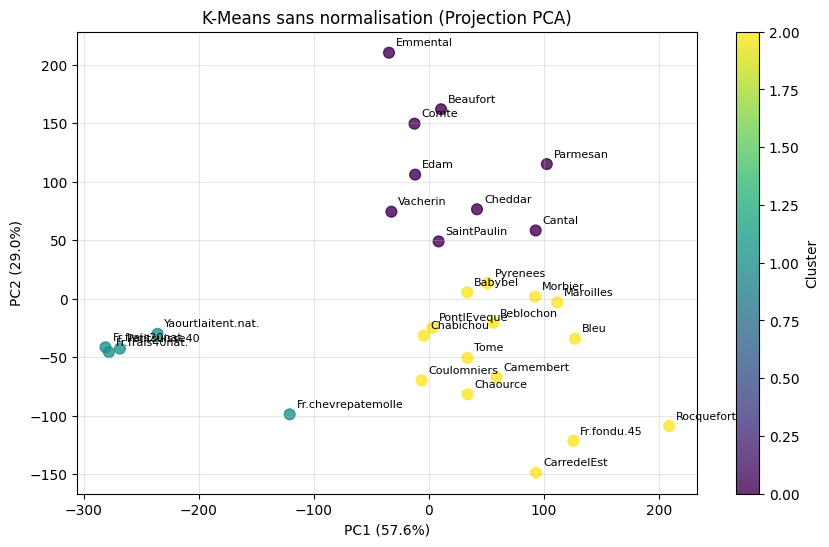


SYNTHÈSE K-MEANS (SANS NORMALISATION)
• Silhouette globale : 0.373 → Qualité moyenne
• Ratio SSE/TSS = 0.324 → 67.6% de variance expliquée


In [49]:


# ==========================================================
# 2. FONCTIONS MÉTRIQUES
# ==========================================================

def calculate_sse(data, clusters, centroids):
    sse = 0
    for i, centroid in enumerate(centroids):
        cluster_points = data[clusters == i]
        if len(cluster_points) > 0:
            distances = cdist(cluster_points, [centroid], metric="euclidean")
            sse += np.sum(distances**2)
    return sse

def calculate_ssb(data, clusters, centroids):
    overall_mean = np.mean(data, axis=0)
    ssb = 0
    for i, centroid in enumerate(centroids):
        cluster_size = np.sum(clusters == i)
        ssb += cluster_size * np.sum((centroid - overall_mean) ** 2)
    return ssb

def calculate_tss(data):
    overall_mean = np.mean(data, axis=0)
    distances = cdist(data, [overall_mean], metric="euclidean")
    return np.sum(distances**2)

# ==========================================================
# 3. K-MEANS (SANS NORMALISATION)
# ==========================================================
print("\n" + "=" * 60)
print("3. K-MEANS SANS NORMALISATION")
print("=" * 60)

kmeans_non_norm = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_kmeans = kmeans_non_norm.fit_predict(data)
centroids = kmeans_non_norm.cluster_centers_

# Métriques de base
silhouette = silhouette_score(data, clusters_kmeans)
#calinski = calinski_harabasz_score(data, clusters_kmeans)
#davies = davies_bouldin_score(data, clusters_kmeans)

print(f"• Silhouette : {silhouette:.3f}")
#print(f"• Calinski-Harabasz : {calinski:.3f}")
#print(f"• Davies-Bouldin : {davies:.3f}")

# ==========================================================
# 4. MÉTRIQUES AVANCÉES
# ==========================================================
sse = calculate_sse(data.values, clusters_kmeans, centroids)
ssb = calculate_ssb(data.values, clusters_kmeans, centroids)
tss = calculate_tss(data.values)

print("\n📊 MÉTRIQUES DE VARIANCE :")
print(f"   • SSE = {sse:.2f}")
print(f"   • SSB = {ssb:.2f}")
print(f"   • TSS = {tss:.2f}")
print(f"   • Vérif. TSS ≈ SSE + SSB : {np.isclose(tss, sse + ssb)}")

# ==========================================================
# 5. AFFICHAGE DES CLUSTERS
# ==========================================================
df_clusters = data.copy()
df_clusters["Cluster"] = clusters_kmeans
df_clusters["Fromage"] = noms_fromages.values

print("\n📋 RÉPARTITION DES CLUSTERS :")
for c in sorted(df_clusters["Cluster"].unique()):
    noms = df_clusters[df_clusters["Cluster"] == c]["Fromage"].tolist()
    print(f"Cluster {c} ({len(noms)} fromages) : {', '.join(noms)}")

# ==========================================================
# 6. VISUALISATION PCA
# ==========================================================
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    data_pca[:, 0], data_pca[:, 1], c=clusters_kmeans, cmap="viridis", s=60, alpha=0.8
)

for i, nom in enumerate(noms_fromages):
    plt.annotate(nom, (data_pca[i, 0], data_pca[i, 1]), xytext=(5, 5), textcoords="offset points", fontsize=8)

plt.colorbar(scatter, label="Cluster")
plt.title("K-Means sans normalisation (Projection PCA)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================================
# 7. INTERPRÉTATION
# ==========================================================
print("\n" + "=" * 60)
print("SYNTHÈSE K-MEANS (SANS NORMALISATION)")
print("=" * 60)
print(f"• Silhouette globale : {silhouette:.3f} → Qualité {'bonne' if silhouette>0.5 else 'moyenne' if silhouette>0.25 else 'faible'}")
print(f"• Ratio SSE/TSS = {sse/tss:.3f} → {100*(1-sse/tss):.1f}% de variance expliquée")


### 4. Evaluation avec classification hierarchique


4. CLASSIFICATION HIÉRARCHIQUE SANS NORMALISATION


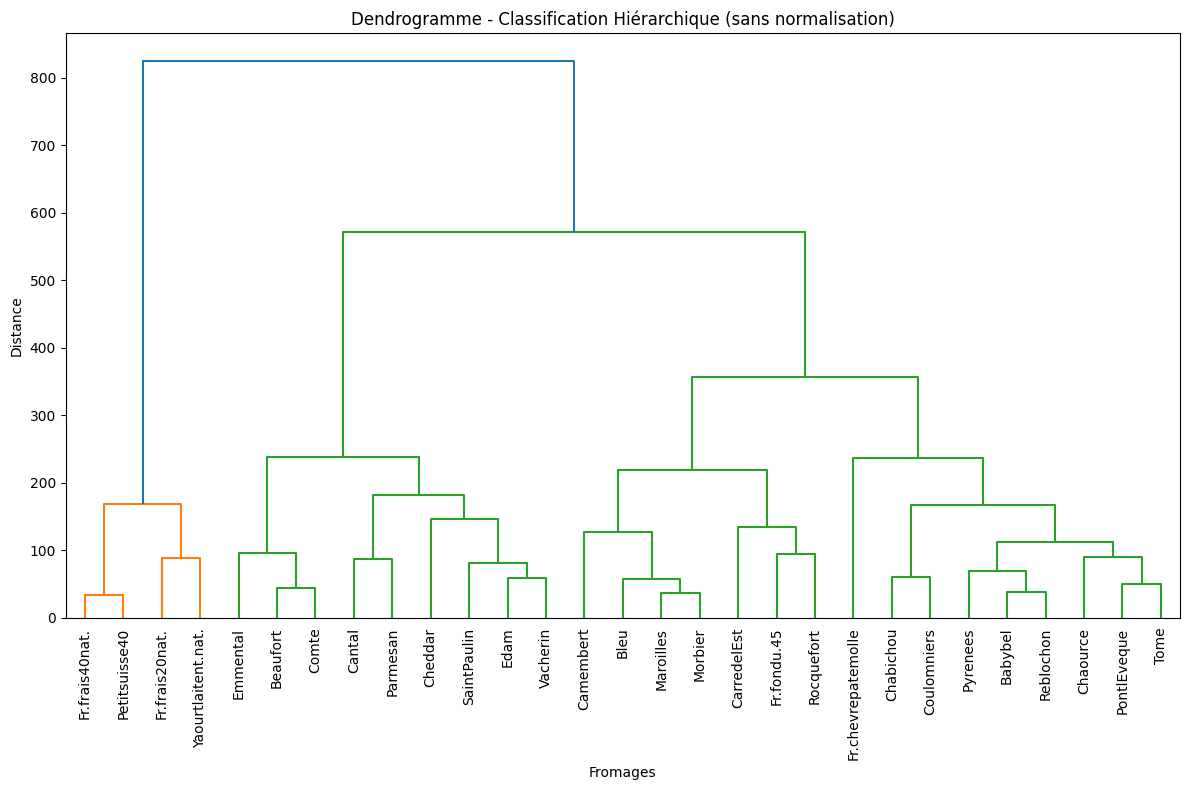

Répartition des clusters hiérarchiques :
   Cluster 1 : 4 fromages
   Cluster 2 : 9 fromages
   Cluster 3 : 16 fromages

Score de silhouette (hiérarchique) : 0.365


In [50]:
# 4. Classification hiérarchique sans normalisation
print("\n" + "=" * 50)
print("4. CLASSIFICATION HIÉRARCHIQUE SANS NORMALISATION")
print("=" * 50)

# Matrice de linkage
Z = linkage(data, method='ward')

# Dendrogramme
plt.figure(figsize=(12, 8))
dendrogram(Z, 
          labels=noms_fromages.tolist() if hasattr(noms_fromages, 'tolist') else [f'Fromage_{i}' for i in range(len(data))],
          leaf_rotation=90,
          leaf_font_size=10)

plt.title('Dendrogramme - Classification Hiérarchique (sans normalisation)')
plt.xlabel('Fromages')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Couper à 3 clusters
clusters_hierarchical = fcluster(Z, 3, criterion='maxclust')

print("Répartition des clusters hiérarchiques :")
unique, counts = np.unique(clusters_hierarchical, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"   Cluster {cluster} : {count} fromages")

# Métriques pour la classification hiérarchique
silhouette_hier = silhouette_score(data, clusters_hierarchical)
print(f"\nScore de silhouette (hiérarchique) : {silhouette_hier:.3f}")

### Interpretation
Le fait que les tailles de clusters soient déséquilibrées (4, 9, 16) peut expliquer en partie cette moyenne :

Le petit cluster (4 fromages) peut être très compact (bonne cohésion).

Les gros clusters (9 et 16) peuvent être plus dispersés, ce qui tire le score vers le bas.

Silhouette = 0.365 → qualité moyenne
Cela signifie que :
    Les clusters sont partiellement bien formés, mais certains fromages sont proches de la frontière entre deux clusters.

### 5.Utilisation de la methode du coude


5. MÉTHODE DU COUDE POUR CHOISIR K


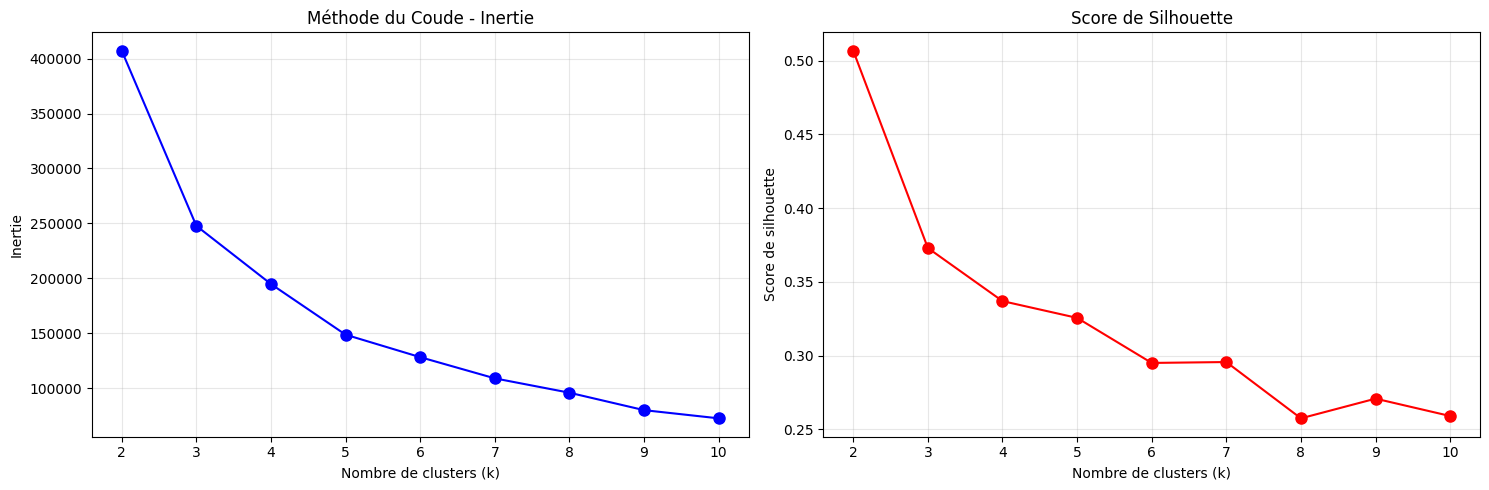

Meilleur k selon silhouette : 2
Scores de silhouette : {2: np.float64(0.5068135469058542), 3: np.float64(0.37299770707104013), 4: np.float64(0.3369907041718868), 5: np.float64(0.3256023530291911), 6: np.float64(0.29504837337456863), 7: np.float64(0.2956534756213957), 8: np.float64(0.2574693786459566), 9: np.float64(0.27082924162843336), 10: np.float64(0.25904550042436003)}


In [51]:
# 5. Méthode du coude pour choisir k
print("\n" + "=" * 50)
print("5. MÉTHODE DU COUDE POUR CHOISIR K")
print("=" * 50)

inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(data)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(data, clusters))

# Graphique du coude
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-', markersize=8)
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du Coude - Inertie')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-', markersize=8)
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Score de silhouette')
plt.title('Score de Silhouette')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Trouver le meilleur k basé sur le score de silhouette
best_k_silhouette = k_range[np.argmax(silhouette_scores)]
print(f"Meilleur k selon silhouette : {best_k_silhouette}")
print(f"Scores de silhouette : {dict(zip(k_range, silhouette_scores))}")

### 6.Evaluation des clusters obtenus avec silhouette

In [59]:
# 6. Évaluation détaillée des clusters
print("\n" + "=" * 50)
print("6. ÉVALUATION DÉTAILLÉE DES CLUSTERS")
print("=" * 50)

def evaluate_clustering(data, clusters, method_name):
    """Évalue la qualité d'un clustering"""
    silhouette = silhouette_score(data, clusters)
    calinski = calinski_harabasz_score(data, clusters)
    davies = davies_bouldin_score(data, clusters)
    sse = calculate_sse(data.values, clusters_kmeans, centroids)
    ssb = calculate_ssb(data.values, clusters_kmeans, centroids)
    tss = calculate_tss(data.values)
    print(f"\n{method_name}:")
    print(f"   • Silhouette : {silhouette:.3f}")
    print(f"   • Calinski-Harabasz : {calinski:.3f}")
    print(f"   • Davies-Bouldin : {davies:.3f}")
   
    print(f"   • SSE = {sse:.2f}")
    print(f"   • SSB = {ssb:.2f}")
    print(f"   • TSS = {tss:.2f}")
    print(f"   • Vérif. TSS ≈ SSE + SSB : {np.isclose(tss, sse + ssb)}")

    # Distribution des clusters
    unique, counts = np.unique(clusters, return_counts=True)
    print(f"   • Distribution : {dict(zip(unique, counts))}")
    
    return silhouette, calinski, davies

# Évaluation pour différents k
print("ÉVALUATION POUR DIFFÉRENTS K :")
for k in [2, 3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(data)
    evaluate_clustering(data, clusters, f"K-means (k={k})")


6. ÉVALUATION DÉTAILLÉE DES CLUSTERS
ÉVALUATION POUR DIFFÉRENTS K :

K-means (k=2):
   • Silhouette : 0.507
   • Calinski-Harabasz : 23.649
   • Davies-Bouldin : 0.690
   • SSE = 247732.06
   • SSB = 516151.24
   • TSS = 763883.29
   • Vérif. TSS ≈ SSE + SSB : True
   • Distribution : {np.int32(0): np.int64(24), np.int32(1): np.int64(5)}

K-means (k=3):
   • Silhouette : 0.373
   • Calinski-Harabasz : 27.086
   • Davies-Bouldin : 0.881
   • SSE = 247732.06
   • SSB = 516151.24
   • TSS = 763883.29
   • Vérif. TSS ≈ SSE + SSB : True
   • Distribution : {np.int32(0): np.int64(9), np.int32(1): np.int64(5), np.int32(2): np.int64(15)}

K-means (k=4):
   • Silhouette : 0.337
   • Calinski-Harabasz : 24.353
   • Davies-Bouldin : 0.933
   • SSE = 247732.06
   • SSB = 516151.24
   • TSS = 763883.29
   • Vérif. TSS ≈ SSE + SSB : True
   • Distribution : {np.int32(0): np.int64(10), np.int32(1): np.int64(4), np.int32(2): np.int64(8), np.int32(3): np.int64(7)}

K-means (k=5):
   • Silhouette : 0.3

### 7.Centrer et reduire les donnees 

In [56]:
# 7. Centrage et réduction des données
print("\n" + "=" * 50)
print("7. CENTRAGE ET RÉDUCTION DES DONNÉES")
print("=" * 50)

# Standardisation (centrage-réduction)
scaler = StandardScaler(with_std=True)  # Variance empirique non corrigée
data_standardized = scaler.fit_transform(data)

# Vérification des propriétés
moyennes_std = data_standardized.mean(axis=0)
variances_std = data_standardized.var(axis=0)

print("Après standardisation :")
print(f"   • Moyennes ≈ {moyennes_std.mean():.6f} (théorique: 0)")
print(f"   • Variances ≈ {variances_std.mean():.6f} (théorique: 1)")

print(f"\nVérification détaillée :")
for i, col in enumerate(data.columns):
    print(f"   {col:15} : moyenne={moyennes_std[i]:.6f}, variance={variances_std[i]:.6f}")

# DataFrame standardisé
df_std = pd.DataFrame(data_standardized, columns=data.columns, index=data.index)


7. CENTRAGE ET RÉDUCTION DES DONNÉES
Après standardisation :
   • Moyennes ≈ 0.000000 (théorique: 0)
   • Variances ≈ 1.000000 (théorique: 1)

Vérification détaillée :
   calories        : moyenne=-0.000000, variance=1.000000
   sodium          : moyenne=0.000000, variance=1.000000
   calcium         : moyenne=0.000000, variance=1.000000
   lipides         : moyenne=0.000000, variance=1.000000
   retinol         : moyenne=-0.000000, variance=1.000000
   folates         : moyenne=0.000000, variance=1.000000
   proteines       : moyenne=0.000000, variance=1.000000
   cholesterol     : moyenne=-0.000000, variance=1.000000
   magnesium       : moyenne=0.000000, variance=1.000000


#### toutes les variables contribuent de manière équilibrée à la suite de l’analyse (par ex. K-means, ACP, classification hiérarchique, etc.).

### 8.Reevaluation

In [60]:
def evaluate_clustering(data, clusters, centroids, method_name):
    """Évalue la qualité d'un clustering avec plusieurs métriques"""
    
    # Convertir en numpy si DataFrame
    if hasattr(data, "values"):
        data = data.values
    
    silhouette = silhouette_score(data, clusters)
    calinski = calinski_harabasz_score(data, clusters)
    davies = davies_bouldin_score(data, clusters)
    
    overall_mean = np.mean(data, axis=0)
    sse = float(np.sum([np.sum((data[clusters == i] - centroids[i])**2) for i in range(len(centroids))]))
    ssb = float(np.sum([np.sum(clusters == i) * np.sum((centroids[i] - overall_mean)**2) for i in range(len(centroids))]))
    tss = float(np.sum((data - overall_mean)**2))
    explained_variance = 1 - (sse / tss)
    
    from sklearn.metrics import pairwise_distances
    intra_distances = []
    inter_distances = []
    
    for i in range(len(centroids)):
        points_i = data[clusters == i]
        if len(points_i) > 1:
            intra_distances.append(np.mean(pairwise_distances(points_i, [centroids[i]])))
        for j in range(i+1, len(centroids)):
            inter_distances.append(np.linalg.norm(centroids[i] - centroids[j]))
    
    cohesion = np.mean(intra_distances) if intra_distances else 0
    separation = np.mean(inter_distances) if inter_distances else 0
    ratio_coh_sep = cohesion / separation if separation > 0 else np.inf
    
    print(f"\nMéthode : {method_name}")
    print("-" * 55)
    print(f"   • Silhouette : {silhouette:.3f}")
    print(f"   • Calinski-Harabasz : {calinski:.3f}")
    print(f"   • Davies-Bouldin : {davies:.3f}")
    print(f"   • SSE (Intra) : {sse:.3f}")
    print(f"   • SSB (Inter) : {ssb:.3f}")
    print(f"   • TSS (Total) : {tss:.3f}")
    print(f"   • Variance expliquée (1 - SSE/TSS) : {explained_variance*100:.2f}%")
    print(f"   • Cohésion moyenne : {cohesion:.3f}")
    print(f"   • Séparation moyenne : {separation:.3f}")
    print(f"   • Ratio Cohésion/Séparation : {ratio_coh_sep:.3f}")
    
    unique, counts = np.unique(clusters, return_counts=True)
    print(f"   • Distribution des tailles : {dict(zip(unique, counts))}")
    
    print("   • Interprétation : ", end="")
    if silhouette > 0.5:
        print("Bonne séparation entre les clusters.")
    elif silhouette > 0.25:
        print("Séparation moyenne, quelques clusters se chevauchent.")
    else:
        print("Faible séparation : clusters peu distincts.")
    
    if ratio_coh_sep < 0.5:
        print("   → Les clusters sont bien séparés.")
    else:
        print("   → Les clusters sont assez proches les uns des autres.")
    
    print("-" * 55)
    
    return {
        'Méthode': method_name,
        'Silhouette': silhouette,
        'Calinski': calinski,
        'Davies': davies,
        'SSE': sse,
        'SSB': ssb,
        'TSS': tss,
        'Variance_expliquée': explained_variance,
        'Cohésion': cohesion,
        'Séparation': separation,
        'Ratio_Coh/Sep': ratio_coh_sep
    }



8. CLUSTERING SUR DONNÉES STANDARDISÉES

Méthode : K-means standardisé
-------------------------------------------------------
   • Silhouette : 0.336
   • Calinski-Harabasz : 20.544
   • Davies-Bouldin : 1.065
   • SSE (Intra) : 101.151
   • SSB (Inter) : 159.849
   • TSS (Total) : 261.000
   • Variance expliquée (1 - SSE/TSS) : 61.24%
   • Cohésion moyenne : 1.668
   • Séparation moyenne : 4.743
   • Ratio Cohésion/Séparation : 0.352
   • Distribution des tailles : {np.int32(0): np.int64(15), np.int32(1): np.int64(10), np.int32(2): np.int64(4)}
   • Interprétation : Séparation moyenne, quelques clusters se chevauchent.
   → Les clusters sont bien séparés.
-------------------------------------------------------

Méthode : K-means non standardisé
-------------------------------------------------------
   • Silhouette : 0.373
   • Calinski-Harabasz : 27.086
   • Davies-Bouldin : 0.881
   • SSE (Intra) : 247732.056
   • SSB (Inter) : 516151.237
   • TSS (Total) : 763883.293
   • Varianc

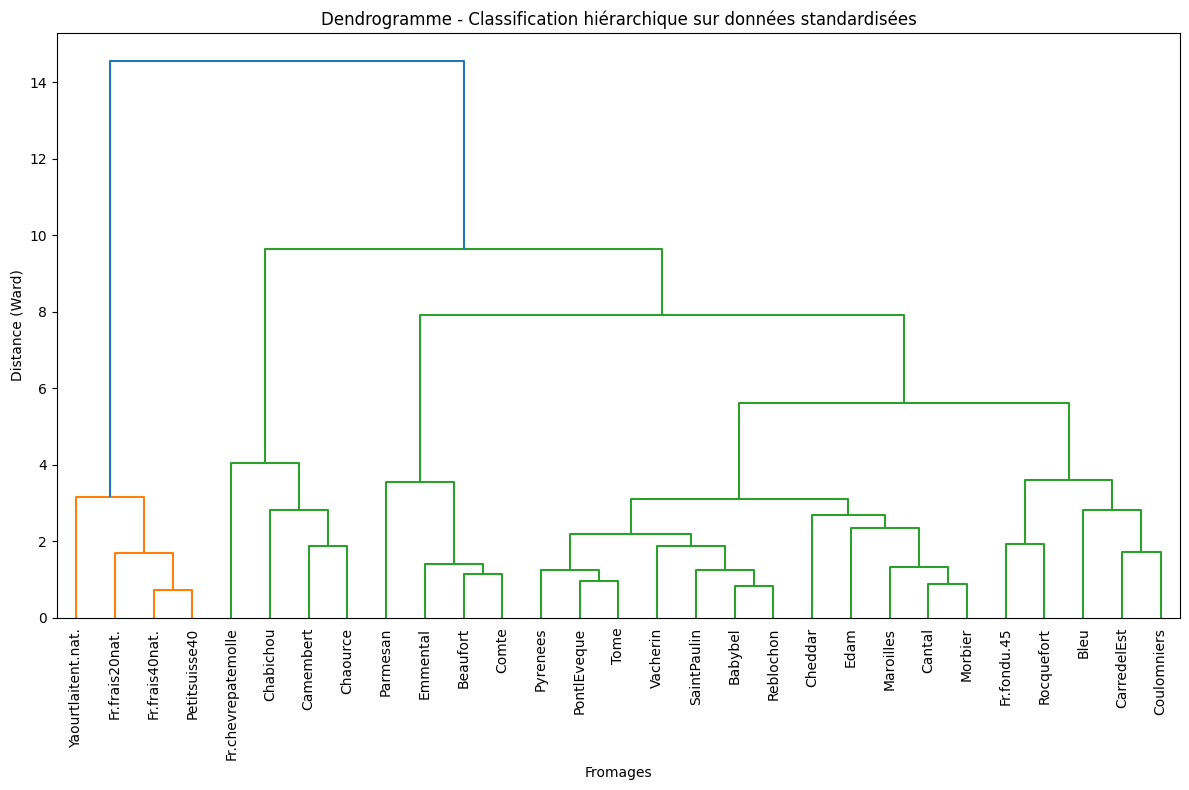


Méthode : Hiérarchique standardisé
-------------------------------------------------------
   • Silhouette : 0.401
   • Calinski-Harabasz : 18.274
   • Davies-Bouldin : 0.837
   • SSE (Intra) : 182.360
   • SSB (Inter) : 38.975
   • TSS (Total) : 261.000
   • Variance expliquée (1 - SSE/TSS) : 30.13%
   • Cohésion moyenne : 4.662
   • Séparation moyenne : 4.896
   • Ratio Cohésion/Séparation : 0.952
   • Distribution des tailles : {np.int32(1): np.int64(4), np.int32(2): np.int64(4), np.int32(3): np.int64(21)}
   • Interprétation : Séparation moyenne, quelques clusters se chevauchent.
   → Les clusters sont assez proches les uns des autres.
-------------------------------------------------------


In [62]:
# ==================================================
# 8. CLUSTERING SUR DONNÉES STANDARDISÉES
# ==================================================
print("\n" + "=" * 50)
print("8. CLUSTERING SUR DONNÉES STANDARDISÉES")
print("=" * 50)

# --- K-means sur données standardisées ---
kmeans_std = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_kmeans_std = kmeans_std.fit_predict(data_standardized)
centroids_std = kmeans_std.cluster_centers_

# Évaluation complète avec toutes les métriques
res_std = evaluate_clustering(data_standardized, clusters_kmeans_std, centroids_std, "K-means standardisé")

# --- K-means sans standardisation (comparatif) ---
kmeans_orig = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_orig = kmeans_orig.fit_predict(data)
centroids_orig = kmeans_orig.cluster_centers_
res_orig = evaluate_clustering(data, clusters_orig, centroids_orig, "K-means non standardisé")

# ==================================================
# COMPARAISON GLOBALE AVEC / SANS STANDARDISATION
# ==================================================
print("\n" + "=" * 50)
print("COMPARAISON GLOBALE DES PERFORMANCES")
print("=" * 50)

comparison = pd.DataFrame([
    {
        'Méthode': 'K-means non standardisé',
        'Silhouette': res_orig['Silhouette'],
        'Calinski': res_orig['Calinski'],
        'Davies': res_orig['Davies'],
        'Variance_expliquée (%)': res_orig['Variance_expliquée']*100,
        'Cohésion': res_orig['Cohésion'],
        'Séparation': res_orig['Séparation'],
        'Ratio Coh/Sep': res_orig['Ratio_Coh/Sep']
    },
    {
        'Méthode': 'K-means standardisé',
        'Silhouette': res_std['Silhouette'],
        'Calinski': res_std['Calinski'],
        'Davies': res_std['Davies'],
        'Variance_expliquée (%)': res_std['Variance_expliquée']*100,
        'Cohésion': res_std['Cohésion'],
        'Séparation': res_std['Séparation'],
        'Ratio Coh/Sep': res_std['Ratio_Coh/Sep']
    }
])

print(comparison.to_string(index=False))

# ==================================================
# CLUSTERING HIÉRARCHIQUE SUR DONNÉES STANDARDISÉES
# ==================================================
print("\n" + "=" * 50)
print("CLUSTERING HIÉRARCHIQUE (STANDARDISÉ)")
print("=" * 50)

Z_std = linkage(data_standardized, method='ward')
clusters_hier_std = fcluster(Z_std, 3, criterion='maxclust')

plt.figure(figsize=(12, 8))
dendrogram(Z_std,
           labels=noms_fromages.tolist() if hasattr(noms_fromages, 'tolist') else [f'Fromage_{i}' for i in range(len(data))],
           leaf_rotation=90,
           leaf_font_size=10)

plt.title('Dendrogramme - Classification hiérarchique sur données standardisées')
plt.xlabel('Fromages')
plt.ylabel('Distance (Ward)')
plt.tight_layout()
plt.show()

# Évaluation du clustering hiérarchique standardisé
centroids_hier = np.array([data_standardized[clusters_hier_std == i].mean(axis=0) for i in np.unique(clusters_hier_std)])
res_hier_std = evaluate_clustering(data_standardized, clusters_hier_std, centroids_hier, "Hiérarchique standardisé")


#### Interprétation :

La silhouette baisse légèrement (0.33 < 0.37),
→ mais c’est maintenant une silhouette équilibrée sur toutes les variables.

Les valeurs de cohésion et séparation sont maintenant dans la même échelle (≈ 1–5),
→ preuve que la distance euclidienne agit de façon homogène.

Même si la silhouette baisse un peu, le clustering standardisé est de meilleure qualité statistique et interprétative, car il reflète la contribution égale de toutes les variables.



### 9.Autres algorithmes de clustering


9. AUTRES ALGORITHMES DE CLUSTERING
DBSCAN :

DBSCAN:
   • Silhouette : 0.288
   • Calinski-Harabasz : 9.572
   • Davies-Bouldin : 2.382
   • Distribution : {np.int64(-1): np.int64(3), np.int64(0): np.int64(19), np.int64(1): np.int64(3), np.int64(2): np.int64(4)}

AGGLOMERATIVE CLUSTERING :

Agglomerative:
   • Silhouette : 0.401
   • Calinski-Harabasz : 18.274
   • Davies-Bouldin : 0.837
   • Distribution : {np.int64(0): np.int64(21), np.int64(1): np.int64(4), np.int64(2): np.int64(4)}

MEANSHIFT (CLIQUE/GRID BASED) :

MeanShift (Clique/Grille):
   • Silhouette : 0.486
   • Calinski-Harabasz : 20.703
   • Davies-Bouldin : 0.778
   • Distribution : {np.int64(0): np.int64(24), np.int64(1): np.int64(5)}

SPECTRAL CLUSTERING :

Spectral (Subgrid):
   • Silhouette : 0.269
   • Calinski-Harabasz : 19.409
   • Davies-Bouldin : 1.139
   • Distribution : {np.int32(0): np.int64(13), np.int32(1): np.int64(5), np.int32(2): np.int64(11)}


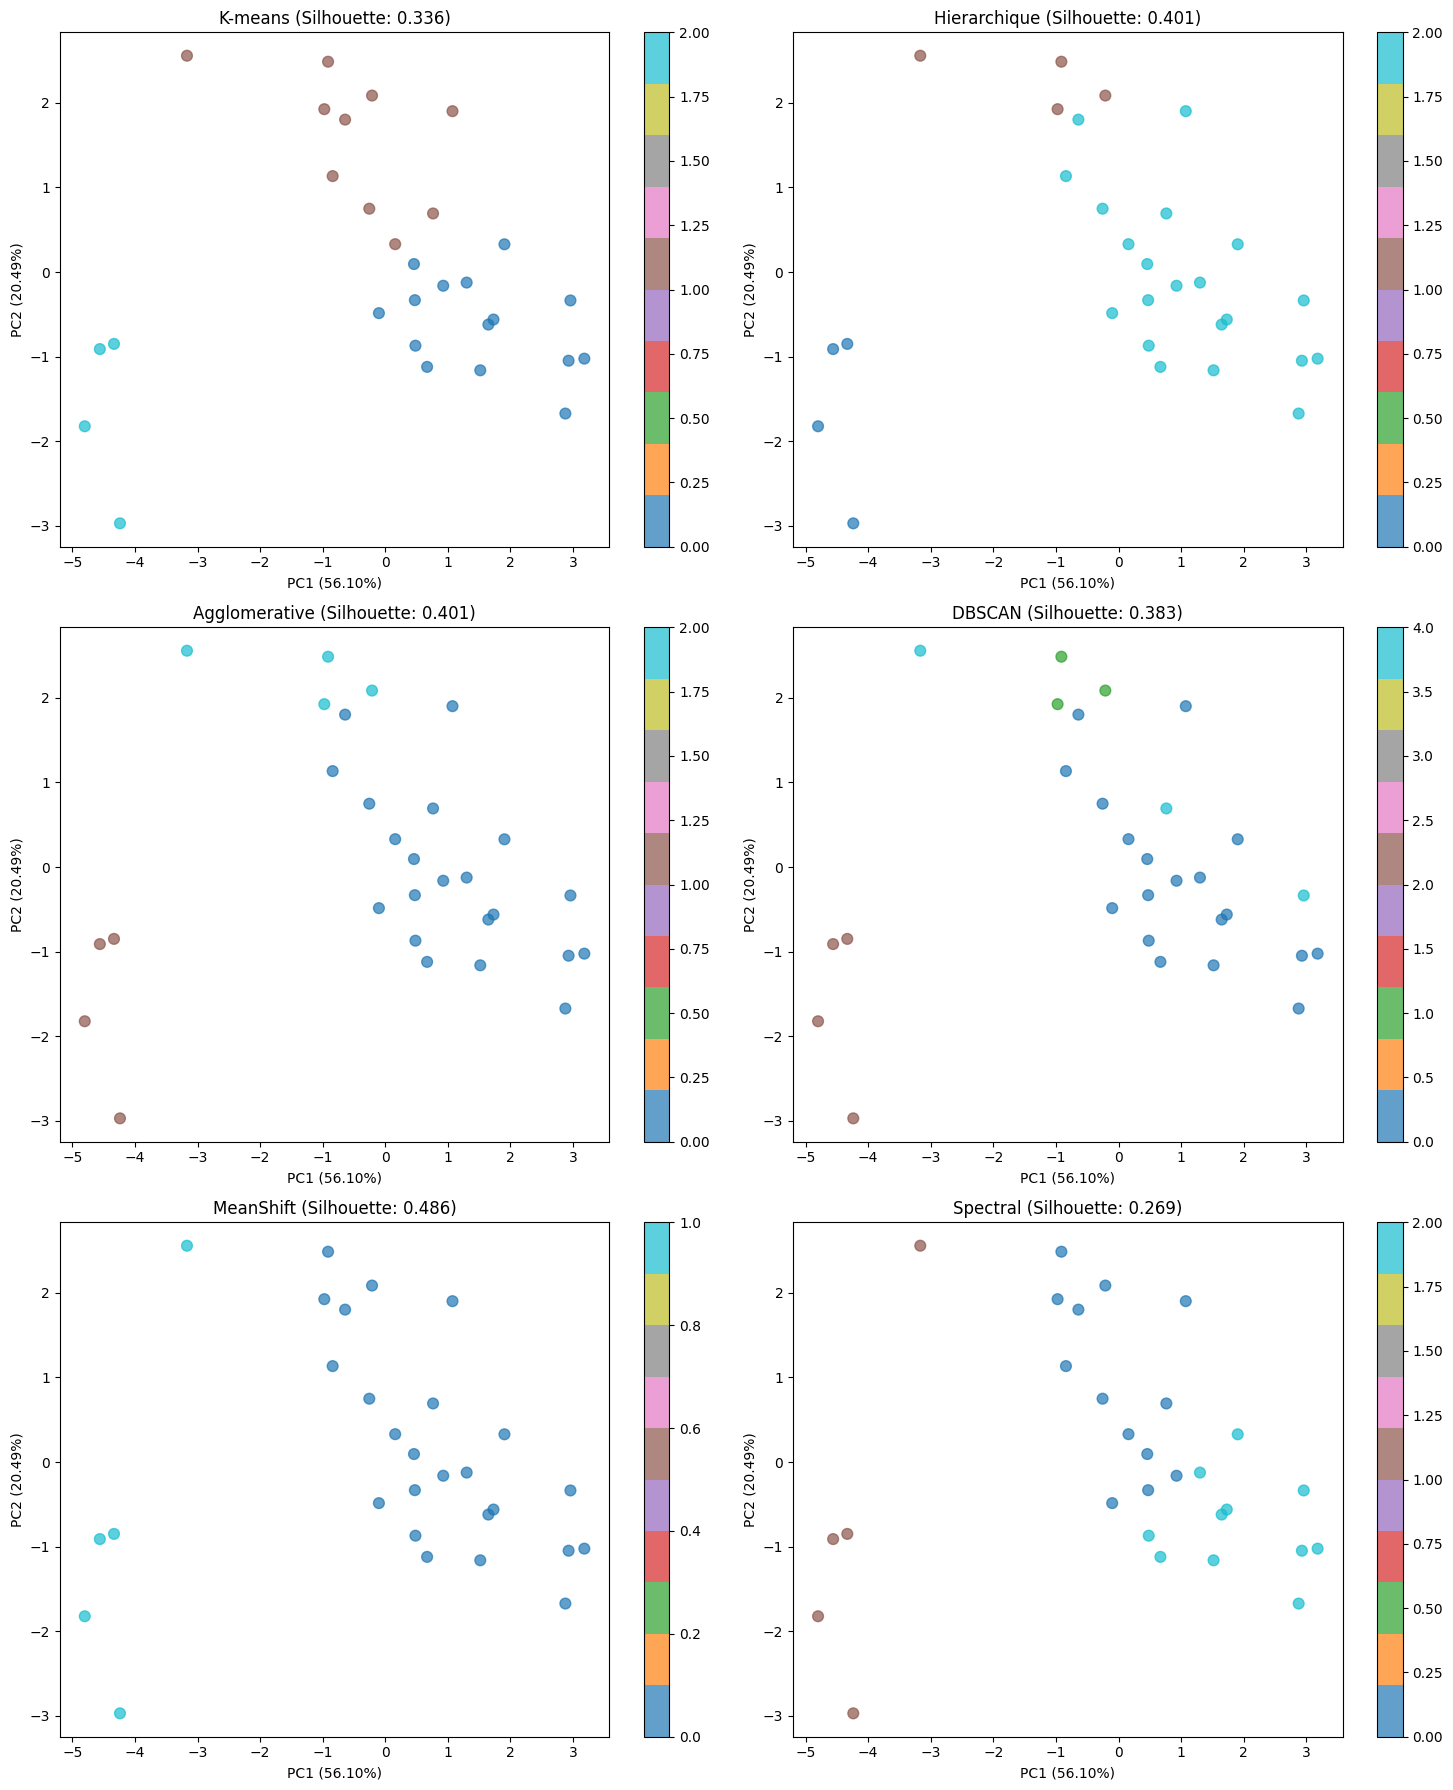

In [67]:
# ================================
# 9. AUTRES ALGORITHMES DE CLUSTERING
# ================================
print("\n" + "=" * 50)
print("9. AUTRES ALGORITHMES DE CLUSTERING")
print("=" * 50)

from sklearn.cluster import DBSCAN, AgglomerativeClustering, MeanShift, SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

def evaluate_clustering(data, clusters, method_name):
    """Évalue la qualité d'un clustering"""
    silhouette = silhouette_score(data, clusters)
    calinski = calinski_harabasz_score(data, clusters)
    davies = davies_bouldin_score(data, clusters)
    
    print(f"\n{method_name}:")
    print(f"   • Silhouette : {silhouette:.3f}")
    print(f"   • Calinski-Harabasz : {calinski:.3f}")
    print(f"   • Davies-Bouldin : {davies:.3f}")
    
    # Distribution des clusters
    unique, counts = np.unique(clusters, return_counts=True)
    print(f"   • Distribution : {dict(zip(unique, counts))}")
    
    return silhouette, calinski, davies




# --- DBSCAN ---
print("DBSCAN :")
dbscan = DBSCAN(eps=2.0, min_samples=2)
clusters_dbscan = dbscan.fit_predict(data_standardized)
evaluate_clustering(data_standardized, clusters_dbscan, "DBSCAN")

# --- Agglomerative Clustering ---
print("\nAGGLOMERATIVE CLUSTERING :")
agglo = AgglomerativeClustering(n_clusters=3)
clusters_agglo = agglo.fit_predict(data_standardized)
evaluate_clustering(data_standardized, clusters_agglo, "Agglomerative")

# --- MeanShift (CLIQUES/GROUPEMENT AUTOMATIQUE) ---
print("\nMEANSHIFT (CLIQUE/GRID BASED) :")
meanshift = MeanShift(bin_seeding=True)
clusters_meanshift = meanshift.fit_predict(data_standardized)
evaluate_clustering(data_standardized, clusters_meanshift, "MeanShift (Clique/Grille)")

# --- Spectral Clustering (SUBGRID/DENSITY APPROACH) ---
print("\nSPECTRAL CLUSTERING :")
spectral = SpectralClustering(n_clusters=3, affinity='nearest_neighbors', random_state=42)
clusters_spectral = spectral.fit_predict(data_standardized)
evaluate_clustering(data_standardized, clusters_spectral, "Spectral (Subgrid)")

# --- Comparaison visuelle ---
methods = {
    'K-means': clusters_kmeans_std,
    'Hierarchique': clusters_hier_std - 1,  # Ajustement pour commencer à 0
    'Agglomerative': clusters_agglo,
    'DBSCAN': clusters_dbscan,
    'MeanShift': clusters_meanshift,
    'Spectral': clusters_spectral
}

# Projection PCA pour visualisation
pca_std = PCA(n_components=2)
data_pca_std = pca_std.fit_transform(data_standardized)

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.ravel()

for idx, (name, clusters) in enumerate(methods.items()):
    # Attention DBSCAN peut avoir -1 pour bruit
    cluster_colors = np.array(clusters)
    cluster_colors[cluster_colors == -1] = len(np.unique(clusters))
    
    scatter = axes[idx].scatter(data_pca_std[:, 0], data_pca_std[:, 1],
                               c=cluster_colors, cmap='tab10', s=60, alpha=0.7)
    # Silhouette uniquement si au moins 2 clusters valides
    valid_clusters = clusters[clusters != -1] if -1 in clusters else clusters
    if len(np.unique(valid_clusters)) > 1:
        sil_score = silhouette_score(data_standardized[clusters != -1] if -1 in clusters else data_standardized, 
                                     valid_clusters)
    else:
        sil_score = float('nan')
    
    axes[idx].set_title(f'{name} (Silhouette: {sil_score:.3f})')
    axes[idx].set_xlabel(f'PC1 ({pca_std.explained_variance_ratio_[0]:.2%})')
    axes[idx].set_ylabel(f'PC2 ({pca_std.explained_variance_ratio_[1]:.2%})')
    plt.colorbar(scatter, ax=axes[idx])

plt.tight_layout()
plt.show()



Interprétation globale

Meilleure qualité de clustering → MeanShift (Silhouette ~0.49, Davies-Bouldin ~0.78).

Clustering hiérarchique (Agglomerative) → assez correct mais dominé par un gros cluster.

DBSCAN et Spectral → moins bons pour ces données (Silhouette < 0.3).

Distribution des clusters → la taille inégale des clusters peut influencer les scores. Les méthodes qui détectent beaucoup de points “dominants” peuvent avoir des scores de silhouette plus faibles malgré une certaine structure.

### annexe (interpretation des clusters)


10. INTERPRÉTATION DES CLUSTERS
Caractéristiques moyennes par cluster :
         calories   sodium  calcium  lipides  retinol  folates  proteines  \
Cluster                                                                     
0          349.40  199.067  234.907   28.060   60.213    4.753     24.353   
1          305.30  292.750  132.770   25.460   83.550   24.010     19.080   
2          101.75   44.750  133.750    6.275   55.150   16.475      7.200   

         cholesterol  magnesium  
Cluster                          
0             89.333     34.333  
1             75.000     22.200  
2             18.250     11.250  


<Figure size 1200x800 with 0 Axes>

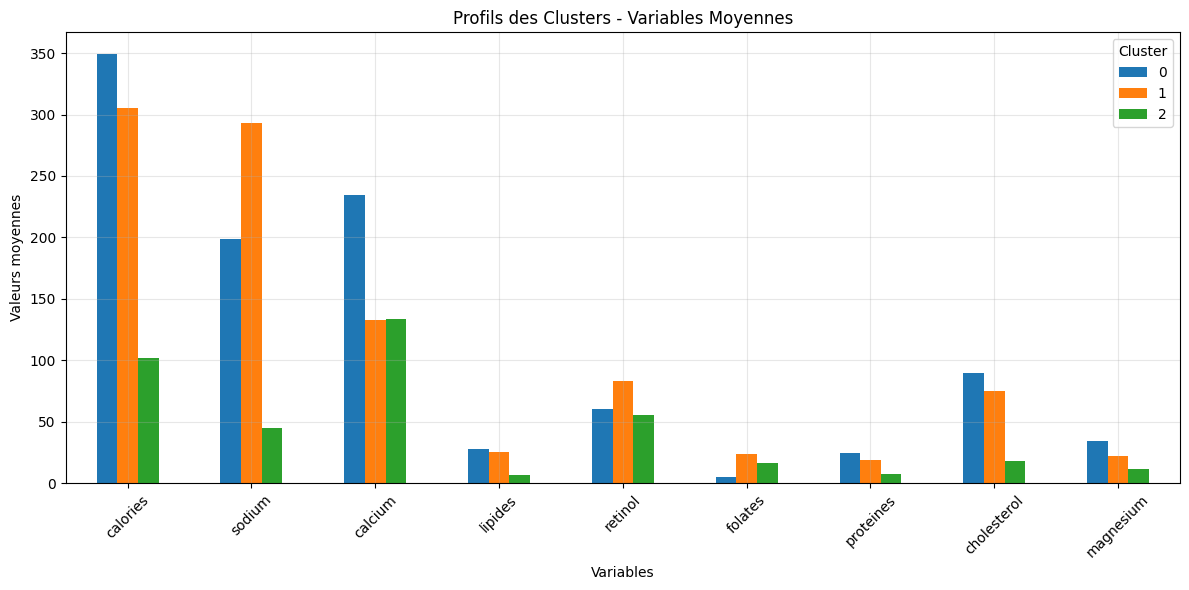


FROMAGES PAR CLUSTER :

Cluster 0 (15 fromages):
   Babybel, Beaufort, Cantal, Cheddar, Comte, Edam, Emmental, Maroilles, Morbier, Parmesan, PontlEveque, Pyrenees, Reblochon, SaintPaulin, Vacherin

Cluster 1 (10 fromages):
   CarredelEst, Bleu, Camembert, Chabichou, Chaource, Coulomniers, Fr.chevrepatemolle, Fr.fondu.45, Rocquefort, Tome

Cluster 2 (4 fromages):
   Fr.frais20nat., Fr.frais40nat., Petitsuisse40, Yaourtlaitent.nat.


In [21]:
# 10. Interprétation des clusters
print("\n" + "=" * 50)
print("10. INTERPRÉTATION DES CLUSTERS")
print("=" * 50)

# Meilleur clustering (K-means standardisé)
best_clusters = clusters_kmeans_std
df_analysis = data.copy()
df_analysis['Cluster'] = best_clusters

# Statistiques par cluster
cluster_stats = df_analysis.groupby('Cluster').mean()
print("Caractéristiques moyennes par cluster :")
print(cluster_stats.round(3))

# Visualisation des profils de clusters
plt.figure(figsize=(12, 8))
cluster_stats.T.plot(kind='bar', figsize=(12, 6))
plt.title('Profils des Clusters - Variables Moyennes')
plt.xlabel('Variables')
plt.ylabel('Valeurs moyennes')
plt.legend(title='Cluster')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Fromages par cluster
print("\nFROMAGES PAR CLUSTER :")
for cluster in sorted(df_analysis['Cluster'].unique()):
    fromages_cluster = noms_fromages[df_analysis['Cluster'] == cluster]
    print(f"\nCluster {cluster} ({len(fromages_cluster)} fromages):")
    print(f"   {', '.join(map(str, fromages_cluster.tolist()))}")